# Exploring factors affecting infant sleep patterns: The role of feeding and developement

**Course:** Data Science - Final project

**Author:** Nikolay Atanasov | **Date:** April 13

--- 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import os

## 1. Introduction
This project aims to explore factors that influence **infant sleep patterns** using multiple datasets. 

## 2. Data Sources

In [2]:
# We use this to list all files and directories in our default directory
os.listdir()

['.git',
 '.ipynb_checkpoints',
 '.virtual_documents',
 'anaconda_projects',
 'Dataset_maternal_mental_health_infant_sleep.csv',
 'Data_Science_project.ipynb',
 'Weights heights of Infants with respect to method of feeding.xlsx']

In [3]:
# Dataset 1: Infant sleep
sleep_df = pd.read_csv("Dataset_maternal_mental_health_infant_sleep.csv", encoding = "latin1")
sleep_df_original = sleep_df.copy() 

# Dataset 2: The role of feeding
feeding_df = pd.read_excel("Weights heights of Infants with respect to method of feeding.xlsx")

C:\Users\liyag\AppData\Local\Temp\ipykernel_34208\658134301.py:2: DtypeWarning: Columns (6,61) have mixed types. Specify dtype option on import or set low_memory=False.
  sleep_df = pd.read_csv("Dataset_maternal_mental_health_infant_sleep.csv", encoding = "latin1")


## 3. Data Understanding

In [4]:
sleep_df_original.head()

,Participant_number,Type_parents,Birth_1mth_M_inclusion,Birth_12mth_M_inclusion,Age,Marital_status,Marital_status_Autre,Marital_status_edit,Education,Gestationnal_age,...,IBQ_R_VSF_10_bb1,IBQ_R_VSF_16_bb1,IBQ_R_VSF_17_bb1,IBQ_R_VSF_28_bb1,IBQ_R_VSF_29_bb1,IBQ_R_VSF_32_bb1,IBQ_R_VSF_33_bb1,Sleep_night_duration_bb1,night_awakening_number_bb1,how_falling_asleep_bb1
0,1.0,1.0,1.0,1.0,34.0,2.0,NaN,2.0,5.0,37.0,...,NaN,7.0,NaN,NaN,7.0,6.0,NaN,10:00,3.0,2.0
1,2.0,1.0,1.0,1.0,33.0,2.0,NaN,2.0,5.0,42.0,...,2.0,3.0,2.0,2.0,2.0,3.0,4.0,11:00,0.0,4.0
2,3.0,1.0,1.0,1.0,37.0,2.0,NaN,2.0,5.0,41.0,...,4.0,4.0,3.0,1.0,4.0,NaN,NaN,12:00,1.0,2.0
3,4.0,1.0,1.0,1.0,31.0,2.0,NaN,2.0,5.0,37.5,...,1.0,3.0,NaN,NaN,NaN,5.0,NaN,11:00,2.0,1.0
4,5.0,1.0,1.0,1.0,36.0,1.0,NaN,1.0,5.0,40.0,...,4.0,2.0,2.0,4.0,5.0,6.0,6.0,10:30,1.0,4.0


In [5]:
feeding_df.head()

,S/n,Weight,Height,Month,Breastfeeding Partern
0,1,4.0,17.0,Month 1,Exclusive Breastfeeding
1,2,4.9,18.5,Month 1,Exclusive Breastfeeding
2,3,5.2,16.0,Month 1,Exclusive Breastfeeding
3,4,4.5,18.0,Month 1,Exclusive Breastfeeding
4,5,5.5,19.0,Month 1,Exclusive Breastfeeding


In [6]:
sleep_df_original.shape

(1048292, 64)

In [7]:
feeding_df.shape

(720, 5)

In [8]:
sleep_df_original.columns

Index(['Participant_number', 'Type_parents', 'Birth_1mth_M_inclusion',
       'Birth_12mth_M_inclusion', 'Age', 'Marital_status',
       'Marital_status_Autre', 'Marital_status_edit', 'Education',
       'Gestationnal_age', 'Type_pregnancy', 'sex_baby1', 'CBTS_M_3',
       'CBTS_M_4', 'CBTS_M_5', 'CBTS_M_6', 'CBTS_M_7', 'CBTS_M_8', 'CBTS_M_9',
       'CBTS_M_10', 'CBTS_M_11', 'CBTS_M_12', 'CBTS_13', 'CBTS_14', 'CBTS_15',
       'CBTS_16', 'CBTS_17', 'CBTS_18', 'CBTS_19', 'CBTS_20', 'CBTS_21',
       'CBTS_22', 'EPDS_1', 'EPDS_2', 'EPDS_3', 'EPDS_4', 'EPDS_5', 'EPDS_6',
       'EPDS_7', 'EPDS_8', 'EPDS_9', 'EPDS_10', 'HADS_1', 'HADS_3', 'HADS_5',
       'HADS_7', 'HADS_9', 'HADS_11', 'HADS_13', 'Child_survey_participation',
       'Age_bb', 'IBQ_R_VSF_3_bb1', 'IBQ_R_VSF_4_bb1', 'IBQ_R_VSF_9_bb1',
       'IBQ_R_VSF_10_bb1', 'IBQ_R_VSF_16_bb1', 'IBQ_R_VSF_17_bb1',
       'IBQ_R_VSF_28_bb1', 'IBQ_R_VSF_29_bb1', 'IBQ_R_VSF_32_bb1',
       'IBQ_R_VSF_33_bb1', 'Sleep_night_duration_bb1',
    

In [9]:
feeding_df.columns

Index(['S/n', 'Weight', 'Height', 'Month', 'Breastfeeding Partern'], dtype='object')

In [10]:
sleep_df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048292 entries, 0 to 1048291
Data columns (total 64 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Participant_number          410 non-null    float64
 1   Type_parents                410 non-null    float64
 2   Birth_1mth_M_inclusion      410 non-null    float64
 3   Birth_12mth_M_inclusion     410 non-null    float64
 4   Age                         410 non-null    float64
 5   Marital_status              410 non-null    float64
 6   Marital_status_Autre        2 non-null      object 
 7   Marital_status_edit         410 non-null    float64
 8   Education                   410 non-null    float64
 9   Gestationnal_age            410 non-null    float64
 10  Type_pregnancy              410 non-null    float64
 11  sex_baby1                   410 non-null    float64
 12  CBTS_M_3                    410 non-null    float64
 13  CBTS_M_4                   

In [11]:
feeding_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   S/n                    720 non-null    int64  
 1   Weight                 720 non-null    float64
 2   Height                 720 non-null    float64
 3   Month                  720 non-null    object 
 4   Breastfeeding Partern  720 non-null    object 
dtypes: float64(2), int64(1), object(2)
memory usage: 28.3+ KB


In [12]:
sleep_df_original.describe()

,Participant_number,Type_parents,Birth_1mth_M_inclusion,Birth_12mth_M_inclusion,Age,Marital_status,Marital_status_edit,Education,Gestationnal_age,Type_pregnancy,...,IBQ_R_VSF_9_bb1,IBQ_R_VSF_10_bb1,IBQ_R_VSF_16_bb1,IBQ_R_VSF_17_bb1,IBQ_R_VSF_28_bb1,IBQ_R_VSF_29_bb1,IBQ_R_VSF_32_bb1,IBQ_R_VSF_33_bb1,night_awakening_number_bb1,how_falling_asleep_bb1
count,410.000000,410.0,410.0,410.0,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,...,376.000000,375.000000,394.000000,329.000000,347.000000,395.000000,378.000000,326.000000,410.000000,410.000000
mean,205.500000,1.0,1.0,1.0,30.197561,2.002439,1.982927,4.080488,39.114146,1.012195,...,3.960106,3.360000,3.195431,2.477204,2.927954,4.326582,4.246032,3.634969,1.439024,3.041463
std,118.501055,0.0,0.0,0.0,4.362262,0.359970,0.225948,1.001642,1.900777,0.109890,...,1.973424,1.969283,1.773391,1.481676,2.121456,1.839272,1.725237,2.176491,1.589218,1.397076
min,1.000000,1.0,1.0,1.0,19.000000,1.000000,1.000000,1.000000,26.500000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,103.250000,1.0,1.0,1.0,27.000000,2.000000,2.000000,3.000000,38.000000,1.000000,...,2.000000,2.000000,2.000000,1.000000,1.000000,3.000000,3.000000,2.000000,0.000000,2.000000
50%,205.500000,1.0,1.0,1.0,30.000000,2.000000,2.000000,4.000000,39.200000,1.000000,...,4.000000,3.000000,3.000000,2.000000,2.000000,4.000000,4.000000,3.000000,1.000000,4.000000
75%,307.750000,1.0,1.0,1.0,33.000000,2.000000,2.000000,5.000000,40.400000,1.000000,...,6.000000,5.000000,4.000000,3.000000,5.000000,6.000000,6.000000,6.000000,2.000000,4.000000
max,410.000000,1.0,1.0,1.0,47.000000,6.000000,3.000000,5.000000,43.000000,2.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,10.000000,5.000000


In [13]:
feeding_df.describe()

,S/n,Weight,Height
count,720.000000,720.000000,720.000000
mean,360.500000,6.040417,20.503056
std,207.990384,1.298707,2.333905
min,1.000000,2.300000,15.000000
25%,180.750000,5.200000,18.800000
50%,360.500000,6.000000,20.450000
75%,540.250000,7.000000,22.225000
max,720.000000,11.200000,26.700000


## 4. Data Cleaning

### 4.1 Missing Values

In [14]:
sleep_df_original.isna().sum()

Participant_number            1047882
Type_parents                  1047882
Birth_1mth_M_inclusion        1047882
Birth_12mth_M_inclusion       1047882
Age                           1047882
                               ...   
IBQ_R_VSF_32_bb1              1047914
IBQ_R_VSF_33_bb1              1047966
Sleep_night_duration_bb1      1047882
night_awakening_number_bb1    1047882
how_falling_asleep_bb1        1047882
Length: 64, dtype: int64

In [15]:
feeding_df.isna().sum()

S/n                      0
Weight                   0
Height                   0
Month                    0
Breastfeeding Partern    0
dtype: int64

### 4.2 Removing Empty Rows

In [16]:
# Removing rows when every single value in that row is missing 
sleep_df = sleep_df.dropna(how = 'all')

In [17]:
sleep_df.shape

(410, 64)

In [18]:
sleep_df.isna().sum()

Participant_number             0
Type_parents                   0
Birth_1mth_M_inclusion         0
Birth_12mth_M_inclusion        0
Age                            0
                              ..
IBQ_R_VSF_32_bb1              32
IBQ_R_VSF_33_bb1              84
Sleep_night_duration_bb1       0
night_awakening_number_bb1     0
how_falling_asleep_bb1         0
Length: 64, dtype: int64

\
Initially, the dataset contained over 1 million rows. 
After inspection, *knowing that there are only 410 participants*,  it was observed that the majority of rows contained only missing values. These rows were removed using:

**sleep_df = sleep_df.dropna(how='all')**

After cleaning, the dataset size was reduced to 410 rows and 64 columns, which represents the actual number of participants.

A new check for missing values showed that most important variables (such as **sleep duration** and **night awakenings**) have no missing data, while some questionnaire-related columns contain a moderate amount of missing values.

In [19]:
print("Before cleaning:", sleep_df_original.shape)
print("After cleaning:", sleep_df.shape)

Before cleaning: (1048292, 64)
After cleaning: (410, 64)


### 4.3 Handling Invalid Values

In [20]:
sleep_df['Sleep_night_duration_bb1'].unique()[:20]

array(['10:00', '11:00', '12:00', '10:30', '08:00', '06:00', '09:00',
       '07:00', '09:30', '05:00', '11:30', '11:15', '99:99', '07:30',
       '08:30'], dtype=object)

In [21]:
sleep_df = sleep_df.copy()

sleep_df['Sleep_night_duration_bb1'] = sleep_df[
    'Sleep_night_duration_bb1'
].replace('99:99', np.nan)

During the data inspection phase, inconsistent and invalid values (e.g., "99:99") were identified in the sleep duration column. These entries do not represent valid time values and were therefore treated as missing data and replaced accordingly ((NaN/NaT).

## 5. Feature Selection

In [22]:
selected_columns = [
    'Sleep_night_duration_bb1',
    'night_awakening_number_bb1',
    'how_falling_asleep_bb1',
    'Age_bb',
    'sex_baby1',
    'Age',
    'Education',
    'Marital_status',
    'Gestationnal_age',
    'Type_pregnancy'
]

sleep_selected = sleep_df[selected_columns].copy()

In [23]:
sleep_selected.head()

,Sleep_night_duration_bb1,night_awakening_number_bb1,how_falling_asleep_bb1,Age_bb,sex_baby1,Age,Education,Marital_status,Gestationnal_age,Type_pregnancy
0,10:00,3.0,2.0,1.0,1.0,34.0,5.0,2.0,37.0,1.0
1,11:00,0.0,4.0,3.0,2.0,33.0,5.0,2.0,42.0,1.0
2,12:00,1.0,2.0,1.0,1.0,37.0,5.0,2.0,41.0,1.0
3,11:00,2.0,1.0,3.0,2.0,31.0,5.0,2.0,37.5,1.0
4,10:30,1.0,4.0,3.0,2.0,36.0,5.0,1.0,40.0,1.0


In [24]:
sleep_selected.shape

(410, 10)

In [25]:
sleep_selected.describe()

,night_awakening_number_bb1,how_falling_asleep_bb1,Age_bb,sex_baby1,Age,Education,Marital_status,Gestationnal_age,Type_pregnancy
count,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000
mean,1.439024,3.041463,1.958537,1.482927,30.197561,4.080488,2.002439,39.114146,1.012195
std,1.589218,1.397076,0.821911,0.500319,4.362262,1.001642,0.359970,1.900777,0.109890
min,0.000000,1.000000,1.000000,1.000000,19.000000,1.000000,1.000000,26.500000,1.000000
25%,0.000000,2.000000,1.000000,1.000000,27.000000,3.000000,2.000000,38.000000,1.000000
50%,1.000000,4.000000,2.000000,1.000000,30.000000,4.000000,2.000000,39.200000,1.000000
75%,2.000000,4.000000,3.000000,2.000000,33.000000,5.000000,2.000000,40.400000,1.000000
max,10.000000,5.000000,3.000000,2.000000,47.000000,5.000000,6.000000,43.000000,2.000000


### Key Observations

- Most infants wake up between 0 and 2 times per night, with a few extreme cases (up to 10 awakenings). This could be an outlier
- Despite the reasonable number of night awakenings, most babies fall asleep in a more difficult/active way (if the scale increases in difficulty)
- The dataset focuses on infants (1–3 months old).
- The distribution of infant sex is approximately balanced.
- Mothers are on average around 30 years old.
- Most mothers have good education when it comes to pregnancy and childbirth
- Most pregnancies are full-term (~39 weeks).
- The mean value of 1 of the type of pregnancies shows that almost all pregnancies proceed normally where 2 shows cases with complication of the pregnancies.

### 6 Feature Engineering / Conversion

In [26]:
sleep_selected['Sleep_night_duration_bb1'] = pd.to_datetime(
    sleep_selected['Sleep_night_duration_bb1'],
    format='%H:%M',  # Example: 10:30
    errors='coerce'  # converts inaccurate information to NaN
)

sleep_selected['Sleep_night_duration_hours'] = (
    sleep_selected['Sleep_night_duration_bb1'].dt.hour +        # takes only the hours: 10:30 --> 10
    sleep_selected['Sleep_night_duration_bb1'].dt.minute / 60   # takes only the minutes: 10:30 --> 30 
)                                                               

In this step, the sleep duration variable was converted from a **time format** (HH:MM) into a **numerical format** (hours), allowing for quantitative analysis and visualization.

After conversion, the sleep duration values are represented as datetime objects with a default date (1900-01-01). Only the time component is relevant for the analysis.

In [27]:
sleep_selected['Sleep_night_duration_hours'].describe()

count    409.000000
mean      10.183985
std        1.432909
min        5.000000
25%       10.000000
50%       10.000000
75%       11.000000
max       12.000000
Name: Sleep_night_duration_hours, dtype: float64

## 7. Exploratory Data Analysis (EDA)

### 7.1 Night Awakenings Distribution

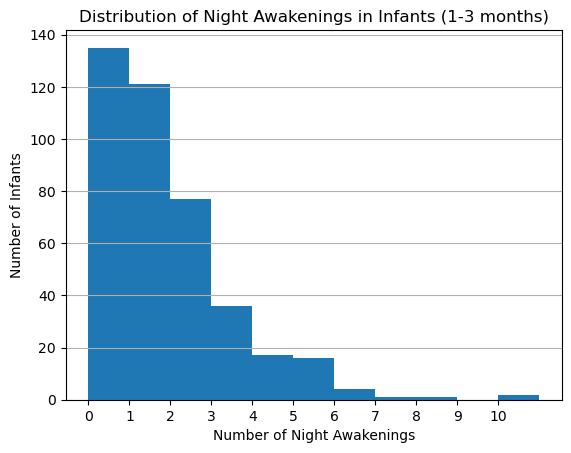

In [28]:
plt.figure()
plt.hist(sleep_selected['night_awakening_number_bb1'], bins=range(0,12))

plt.xlabel("Number of Night Awakenings")
plt.ylabel("Number of Infants")
plt.title("Distribution of Night Awakenings in Infants (1-3 months)")

plt.xticks(range(0,11))  # shows all integers

plt.grid(axis='y')

plt.show()

The histogram shows that most infants wake between 0 and 2 times per night, with a clear concentration around these values.
The distribution is **right-skewed**, indicating that while most infants have relatively few awakenings, there are some extreme cases with significantly higher values (up to 10 awakenings).
Interestingly, there is a noticeable number of cases with 0 awakenings, which may indicate differences in reporting, interpretation of "awakening", or variations in infant sleep behavior.

The relatively low average number of awakenings (around 1.5) appears *lower than expected*, especially for very young infants. This may suggest that factors such as *feeding type* (e.g. breastfeeding vs formula feeding) or *reporting bias* could influence the observed values.

### 7.2 Night Sleep Duration Distribution

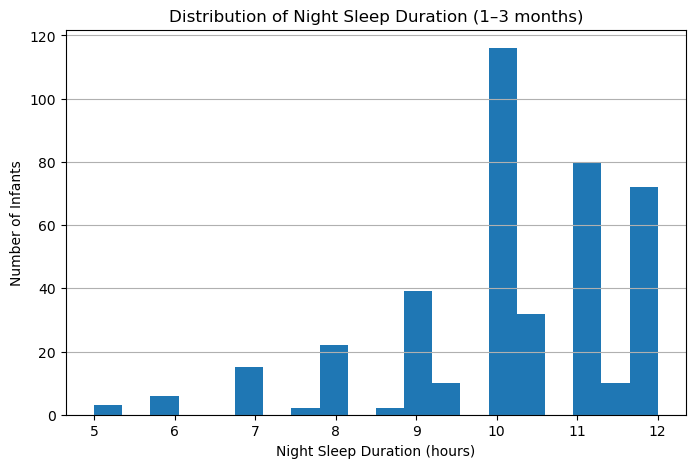

In [31]:
plt.figure(figsize=(8,5))

# Missing values were excluded from the visualization to ensure accurate representation of the distribution.
plt.hist(sleep_selected['Sleep_night_duration_hours'].dropna(), bins=20)

plt.xlabel("Night Sleep Duration (hours)")
plt.ylabel("Number of Infants")
plt.title("Distribution of Night Sleep Duration (1–3 months)")

plt.xticks(range(5, 13))  # shows 5,6,7...12

plt.grid(axis='y')

plt.show()

The distribution of night sleep duration shows that most infants sleep between 10 and 12 hours per night.
The distribution is slightly left-skewed, with a smaller number of infants experiencing significantly shorter sleep durations (5–7 hours).
This indicates variability in early sleep patterns, with a concentration around typical sleep durations but also a subset of infants with reduced sleep. The variability may be influenced by factors such as feeding, sleep routines, or individual differences.

### 7.3 Relationship Between Night Awakenings and Sleep Duration

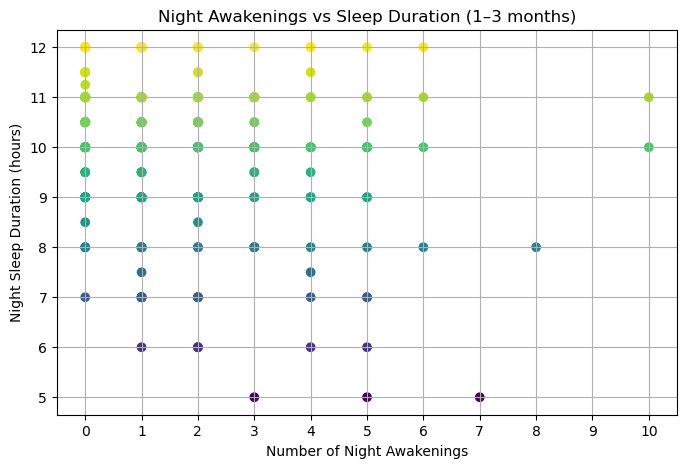

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(
    sleep_selected['night_awakening_number_bb1'],
    sleep_selected['Sleep_night_duration_hours'],
    c=sleep_selected['Sleep_night_duration_hours'],
)

plt.xlabel("Number of Night Awakenings")
plt.ylabel("Night Sleep Duration (hours)")
plt.title("Night Awakenings vs Sleep Duration (1–3 months)")

plt.xticks(range(0,11))

plt.grid(True)

plt.show()

The scatter plot does not show a strong linear relationship between the number of night awakenings and total sleep duration.

While a slight negative trend can be observed (more awakenings tend to be associated with shorter sleep), the relationship is weak and highly variable.

The scatter plot reveals several extreme observations, such as infants with a high number of night awakenings (8–10) but still relatively long total sleep duration. These points may be considered **potential outliers** or reflect variability in sleep patterns, suggesting that total sleep duration alone does not capture sleep quality or fragmentation.

This suggests that the relationship between awakenings and sleep duration is not strictly deterministic.

In [46]:
sleep_selected[['night_awakening_number_bb1', 'Sleep_night_duration_hours']].corr()

,night_awakening_number_bb1,Sleep_night_duration_hours
night_awakening_number_bb1,1.000000,-0.291672
Sleep_night_duration_hours,-0.291672,1.000000


The correlation between the number of night awakenings and total sleep duration is moderately negative (r ≈ -0.29).
This finding is consistent with the scatter plot, where a slight negative trend is visible but with variability across observations.

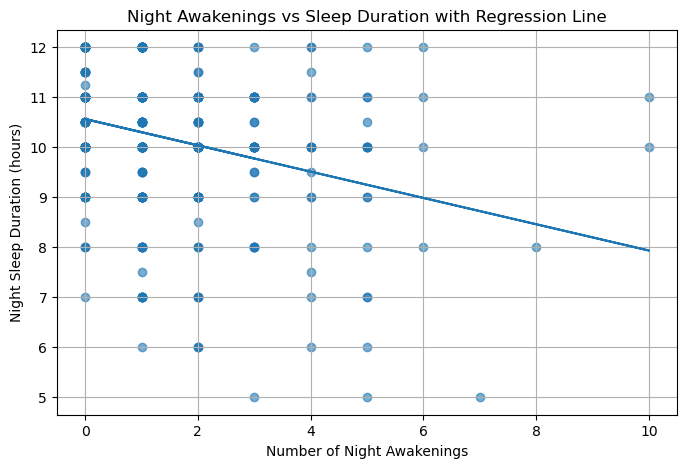

In [49]:
clean_df = sleep_selected[['night_awakening_number_bb1', 'Sleep_night_duration_hours']].dropna()

x = clean_df['night_awakening_number_bb1']
y = clean_df['Sleep_night_duration_hours']

# regression line
slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))

plt.scatter(x, y, alpha=0.6)

plt.plot(x, slope*x + intercept)  # regression line

plt.xlabel("Number of Night Awakenings")
plt.ylabel("Night Sleep Duration (hours)")
plt.title("Night Awakenings vs Sleep Duration with Regression Line")

plt.grid(True)

plt.show()

The **linear regression line** represents the best linear approximation of the relationship between the two variables, capturing the overall trend in the data.

The negative slope of the regression line indicates that an increase in the number of night awakenings is associated with a decrease in total sleep duration.

*Prior to fitting the model, rows with missing values were removed to ensure that the analysis is based on complete observations only.*